In [166]:
!pip install python-dotenv


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from dotenv import load_dotenv  # подключаем .env файл с секретами
import requests  # делаем HTTP-запросы
import os  # читаем переменные окружения
import json

load_dotenv()  # загружаем переменные из .env
CLIENT_ID = 54386297  # получаем CLIENT_ID из .env

# формируем ссылку для получения access_token через OAuth
url = f"https://oauth.vk.com/authorize?client_id={CLIENT_ID}&redirect_uri=https://oauth.vk.com/blank.html&response_type=token&scope=8194"

response = requests.get(url, allow_redirects=True)  # отправляем запрос и следуем редиректам
print(response.url)  # выводим финальный URL, где в адресной строке будет access_token

https://oauth.vk.com/authorize?client_id=54386297&redirect_uri=https://oauth.vk.com/blank.html&response_type=token&scope=8194


In [51]:
access_token = "vk1.a.May--yoh1mJtYSKVETTyTl9ZliEQ03pIAndVXm70WS7ezt_pbfx2WJk7AREPu-V6ezsaJQTYTYotmAaEsRMtYUqRzH3ARQrmI3h5nL85NSQno_3_rfHL4dLQQ0aoWDMbaLqSVuynq3s53IgsTWThTmZRMEY5A7qPQgDFFE36wqHJfcqh8HXatPqKZ7EeSfeCXLsLOj--1O599DcLsmvAhQ"

In [52]:
# Константы (лучше вынести в конфиг или .env)
VK_API_BASE = "https://api.vk.ru/method/"
API_VERSION = "5.131"


def make_vk_request(method, params=None):
    """
    Отправляет GET-запрос к API ВКонтакте.

    :param method: Название метода API (например, 'users.get')
    :param params: Словарь с параметрами запроса (без v и access_token — они добавятся автоматически)
    :return: Ответ API в формате JSON или None при ошибке
    """
    url = f"{VK_API_BASE}{method}"
    # Создаём копию параметров, чтобы не изменять исходный словарь
    request_params = (params or {}).copy()
    # Автоматически добавляем обязательные параметры
    request_params["v"] = API_VERSION
    request_params["access_token"] = access_token

    response = requests.get(url, params=request_params)

    if response.status_code == 200:
        return response.json()
    else:
        print("Ошибка при выполнении запроса:", response.status_code, response.text)
        return None

In [53]:
params = {
    "user_ids": "a.kryukov0",
    "name_case": "nom"
}

data = make_vk_request("users.get", params)

if data:
    print("Ответ:", data)
    if "response" in data:
        result_array = data["response"]
        central_user_id = result_array[0]['id']
        print(f"id пользователя для запроса списка друзей {central_user_id}")
    else:
        print("Ключ 'response' отсутствует в ответе:", data)

Ответ: {'response': [{'id': 253997298, 'first_name': 'Александр', 'last_name': 'Крюков', 'can_access_closed': True, 'is_closed': False}]}
id пользователя для запроса списка друзей 253997298


In [54]:
import requests
import time

CITY_CACHE = {}

def add_city_coords(friend):
    """
    Добавляет в объект друга поля:
      city_lat, city_lon
    используя Nominatim (OpenStreetMap).
    """
    if "city" not in friend or "title" not in friend["city"]:
        return friend  # города нет → нечего добавлять

    city_name = friend["city"]["title"]

    # если уже искали — берём из кеша
    if city_name in CITY_CACHE:
        friend["city_lat"], friend["city_lon"] = CITY_CACHE[city_name]
        return friend

    try:
        url = "https://nominatim.openstreetmap.org/search"
        params = {
            "q": city_name,
            "format": "json",
            "limit": 1
        }
        headers = {"User-Agent": "VK-Student-Project/1.0"}

        r = requests.get(url, params=params, headers=headers)
        data = r.json()

        if data:
            lat = float(data[0]["lat"])
            lon = float(data[0]["lon"])
        else:
            lat, lon = None, None

        CITY_CACHE[city_name] = (lat, lon)

        friend["city_lat"] = lat
        friend["city_lon"] = lon

        time.sleep(1)  # Nominatim ограничивает 1 запрос в секунду

    except Exception as e:
        print(f"[Геокодер ошибка] {city_name}: {e}")
        friend["city_lat"] = None
        friend["city_lon"] = None

    return friend

In [55]:
# Ограничения (API VK имеет лимиты)
MAX_DEPTH = 2
MAX_FRIENDS_PER_USER = 50  # Ограничим для скорости и лимитов
REQUEST_DELAY = 0.35  # Задержка между запросами (в сек), чтобы не превысить лимиты

def get_friends(user_id, fields=None):
    """
    Возвращает список друзей одного пользователя (один уровень).
    Параллельно сохраняет полный ответ friends.get в friends_<id>.json.
    Добавляет lat/lon города через Nominatim.
    """
    try:
        params = {
            "user_id": user_id,
            "count": MAX_FRIENDS_PER_USER
        }
        if fields:
            params["fields"] = fields

        response = make_vk_request("friends.get", params)

        if not response or "error" in response or "response" not in response:
            print(f"[Ошибка VK] user_id={user_id}")
            return []

        payload = response["response"]
        items = payload.get("items", [])

        # --- ДОБАВЛЯЕМ КООРДИНАТЫ ГОРОДА К КАЖДОМУ ДРУГУ ---
        for fr in items:
            add_city_coords(fr)

        # сохраняем json уже с координатами
        filename = f"friends_{user_id}.json"
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=4)

        print(f"Файл сохранён: {filename}")

        return items

    except Exception as e:
        print(f"[Исключение] get_friends({user_id}) -> {e}")
        return []


In [48]:
# Тестируем получение друзей
get_friends(central_user_id, "city,sex,bdate")

Файл сохранён: friends_253997298.json


[{'id': 109210,
  'bdate': '23.7.1989',
  'city': {'id': 109, 'title': 'Пенза'},
  'track_code': 'b799c0deNkEdnw0H98LYa18HeEBTkNYidkETWM7s7ZC8_rJHzb1bKhX6OgX1y4k7b6vn9YP8oTYEKHY2',
  'sex': 1,
  'first_name': 'Инга',
  'last_name': 'Нарбекова',
  'can_access_closed': True,
  'is_closed': False,
  'city_lat': 53.1937836,
  'city_lon': 45.0067413},
 {'id': 5501334,
  'bdate': '10.5',
  'city': {'id': 109, 'title': 'Пенза'},
  'track_code': '9b6c8fdaAFobfWTPFlQ1ZxabHA729Rjjd5GErPUvj2BJ_PWTMPZtMRMfUcIVBWJhJAXotzWAYeB3-OHCkQ',
  'sex': 1,
  'first_name': 'Татьяна',
  'last_name': 'Белоусова',
  'can_access_closed': True,
  'is_closed': False,
  'city_lat': 53.1937836,
  'city_lon': 45.0067413},
 {'id': 6025948,
  'city': {'id': 109, 'title': 'Пенза'},
  'track_code': '0cfd275f6fSXUxVF1Qm1ytZb1RIQ0pD9gkpV4jVvqvMAVS4aH72En51jcEWECeTK4Mkhq9On6f6CIzCMUQ',
  'sex': 1,
  'first_name': 'Мария',
  'last_name': 'Савинкина',
  'can_access_closed': True,
  'is_closed': False,
  'city_lat': 53.1937836,

In [56]:
import json
import csv
from collections import deque
from time import sleep


def build_friends_graph(root_id, fields=None, max_depth=MAX_DEPTH):
    visited = set()
    queue = deque([(root_id, 0)])

    graph_rows = []   # сюда собираем строки для одного CSV
    users_cache = {}  # кеш информации о пользователях

    while queue:
        uid, depth = queue.popleft()
        if depth >= max_depth or uid in visited:
            continue
        visited.add(uid)

        friends = get_friends(uid, fields=fields)

        # инфа о самом пользователе (from_*)
        if uid not in users_cache:
            users_cache[uid] = {}
        from_info = users_cache.get(uid, {})

        from_sex = from_info.get("sex")
        from_city_obj = from_info.get("city") if isinstance(from_info.get("city"), dict) else {}
        from_city = from_city_obj.get("title")
        from_city_lat = from_city_obj.get("lat")
        from_city_lon = from_city_obj.get("lon")
        from_first = from_info.get("first_name")
        from_last = from_info.get("last_name")

        for friend in friends:
            fid = friend["id"]

            # кладём инфу о друге в кеш
            users_cache[fid] = friend

            to_sex = friend.get("sex")
            to_city_obj = friend.get("city") if isinstance(friend.get("city"), dict) else {}
            to_city = to_city_obj.get("title")
            to_city_lat = to_city_obj.get("lat")
            to_city_lon = to_city_obj.get("lon")
            to_first = friend.get("first_name")
            to_last = friend.get("last_name")

            graph_rows.append({
                "from_id": uid,
                "to_id": fid,
                "from_sex": from_sex,
                "to_sex": to_sex,
                "from_city": from_city,
                "to_city": to_city,
                "from_city_lat": from_city_lat,
                "from_city_lon": from_city_lon,
                "to_city_lat": to_city_lat,
                "to_city_lon": to_city_lon,
                "from_first_name": from_first,
                "from_last_name": from_last,
                "to_first_name": to_first,
                "to_last_name": to_last,
            })

            if depth + 1 < max_depth:
                queue.append((fid, depth + 1))

        sleep(REQUEST_DELAY)

    # сохраняем ОДИН CSV
    csv_name = f"friends_graph_{root_id}.csv"
    fieldnames = [
        "from_id", "to_id",
        "from_sex", "to_sex",
        "from_city", "to_city",
        "from_city_lat", "from_city_lon",
        "to_city_lat", "to_city_lon",
        "from_first_name", "from_last_name",
        "to_first_name", "to_last_name",
    ]
    with open(csv_name, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(graph_rows)

    print(f"Граф сохранён в CSV: {csv_name}")
    return graph_rows

In [57]:
graph_rows = build_friends_graph(
    root_id=central_user_id,
    fields="city,sex,bdate",
    max_depth=MAX_DEPTH
)


Файл сохранён: friends_253997298.json
Файл сохранён: friends_109210.json
Файл сохранён: friends_5501334.json
Файл сохранён: friends_6025948.json
[Ошибка VK] user_id=6098838
Файл сохранён: friends_7112155.json
Файл сохранён: friends_7492381.json
Файл сохранён: friends_10379486.json
Файл сохранён: friends_12533719.json
Файл сохранён: friends_16562531.json
Файл сохранён: friends_17107945.json
Файл сохранён: friends_18559160.json
Файл сохранён: friends_24983632.json
Файл сохранён: friends_67747171.json
Файл сохранён: friends_71120919.json
Файл сохранён: friends_82647486.json
[Ошибка VK] user_id=94038568
Файл сохранён: friends_102611347.json
Файл сохранён: friends_107913662.json
Файл сохранён: friends_114429569.json
[Ошибка VK] user_id=115132510
Файл сохранён: friends_126197267.json
[Ошибка VK] user_id=133009875
Файл сохранён: friends_135471189.json
Файл сохранён: friends_141798310.json
Файл сохранён: friends_142655436.json
Файл сохранён: friends_143581002.json
[Ошибка VK] user_id=157350022

In [191]:
!pip install networkx matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


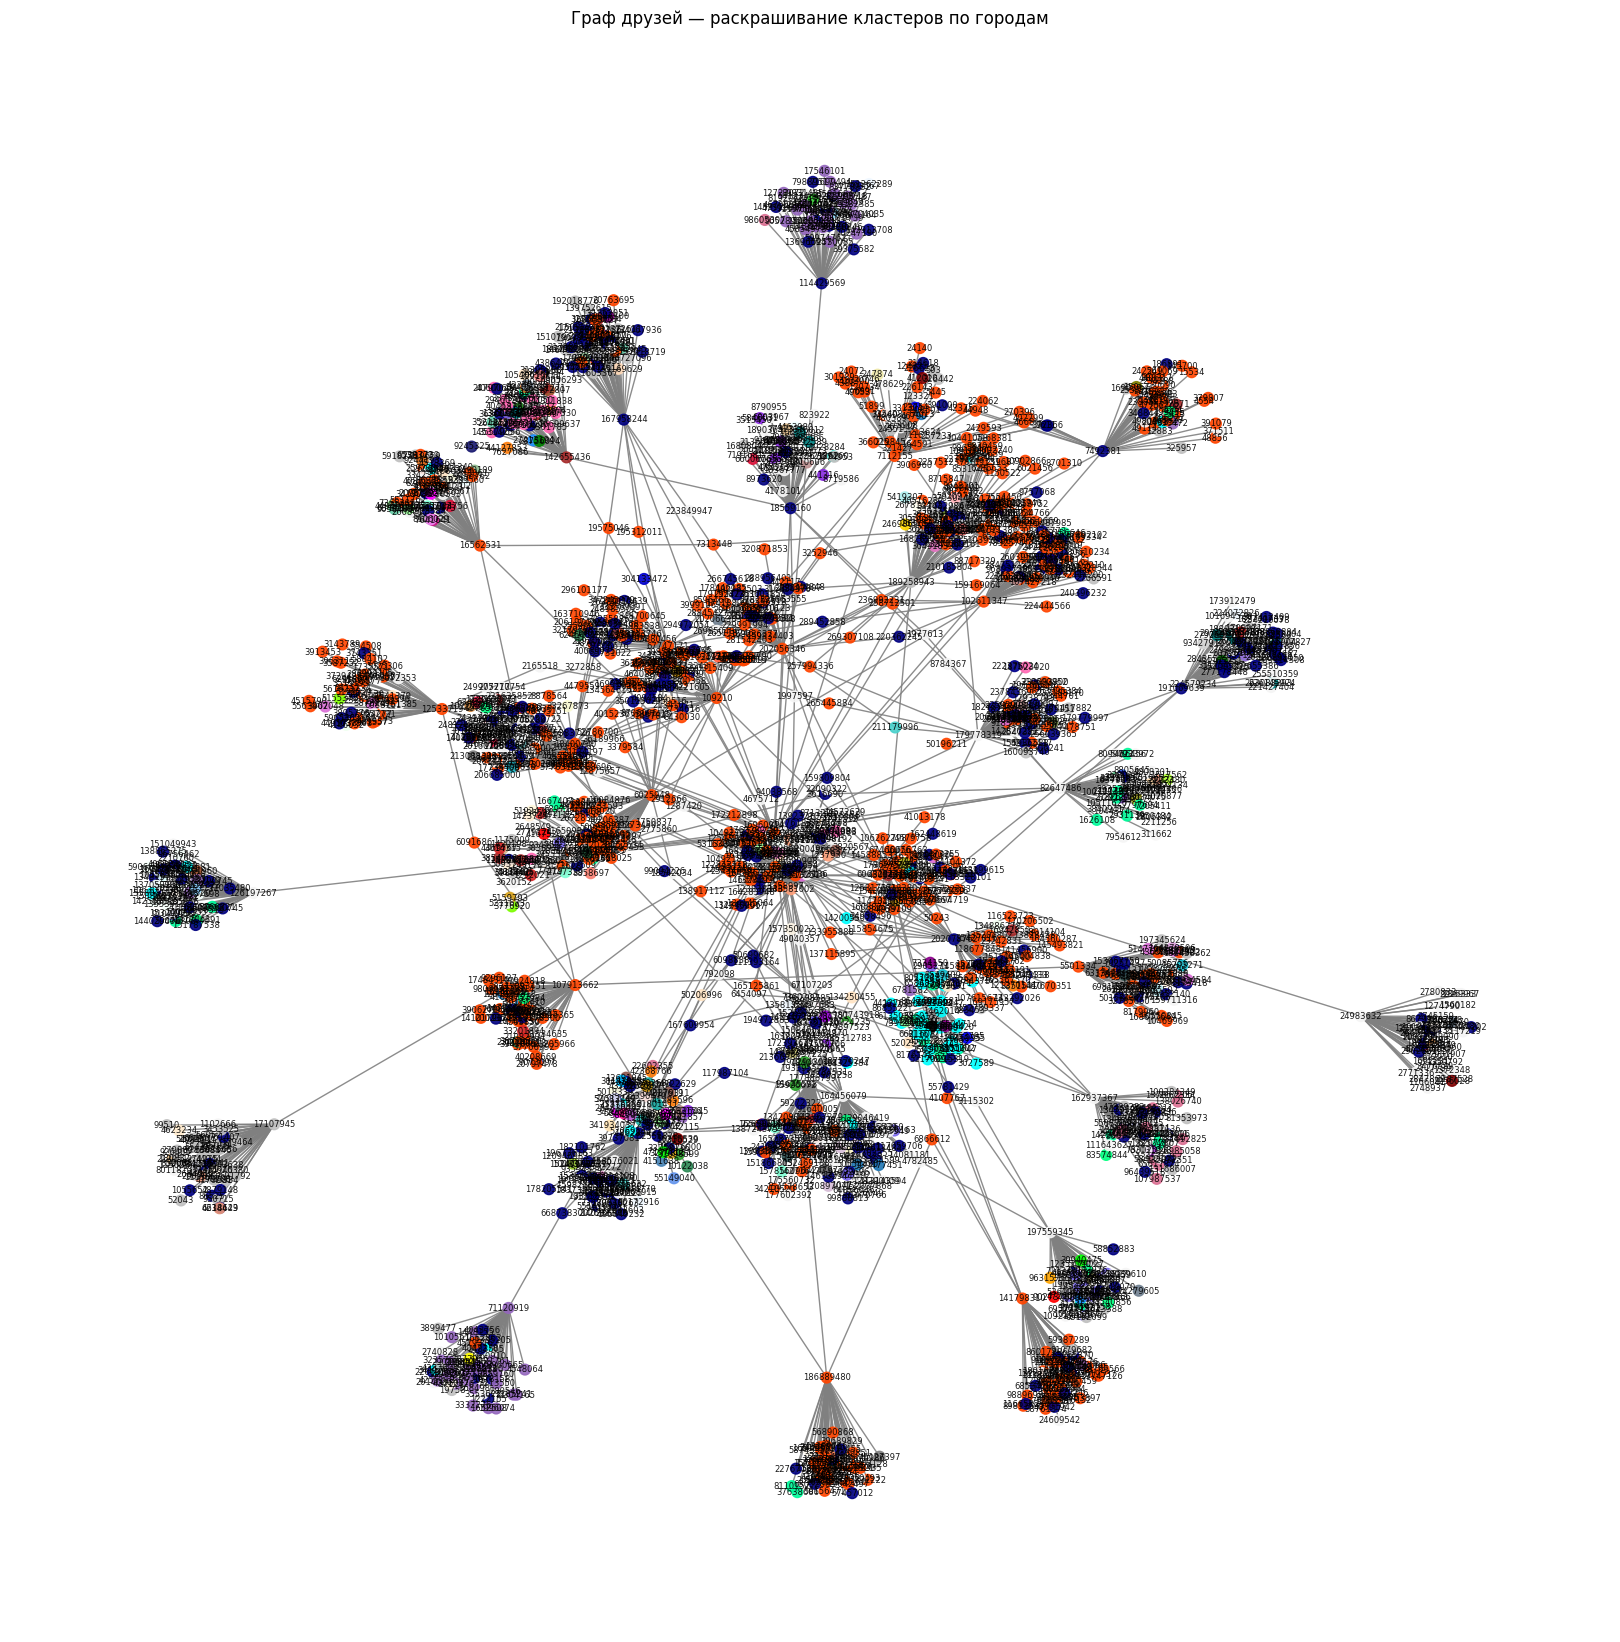

In [58]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# читаем CSV
df = pd.read_csv(f"friends_graph_{central_user_id}.csv")

# строим граф
G = nx.from_pandas_edgelist(df, "from_id", "to_id")

# ---- 1. Собираем города для каждого user_id ----
user_city = {}

# для from_id
for _, row in df.iterrows():
    uid = row["from_id"]
    city = row["from_city"] if pd.notna(row["from_city"]) else "Unknown"
    user_city[uid] = city

    uid2 = row["to_id"]
    city2 = row["to_city"] if pd.notna(row["to_city"]) else "Unknown"
    user_city[uid2] = city2

# список уникальных городов
cities = list(set(user_city.values()))
# print("Найдено городов:", len(cities), cities)

# ---- 2. Генерируем цвета ----
color_palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
city_to_color = {city: color_palette[i % len(color_palette)] for i, city in enumerate(cities)}

# ---- 3. Формируем цвета узлов для графа ----
node_colors = [city_to_color[user_city[node]] for node in G.nodes()]

# ---- 4. Рисуем граф ----
plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    font_size=6,
    node_size=60,
    edge_color="gray",
    alpha=0.9
)

plt.title("Граф друзей — раскрашивание кластеров по городам")
plt.show()


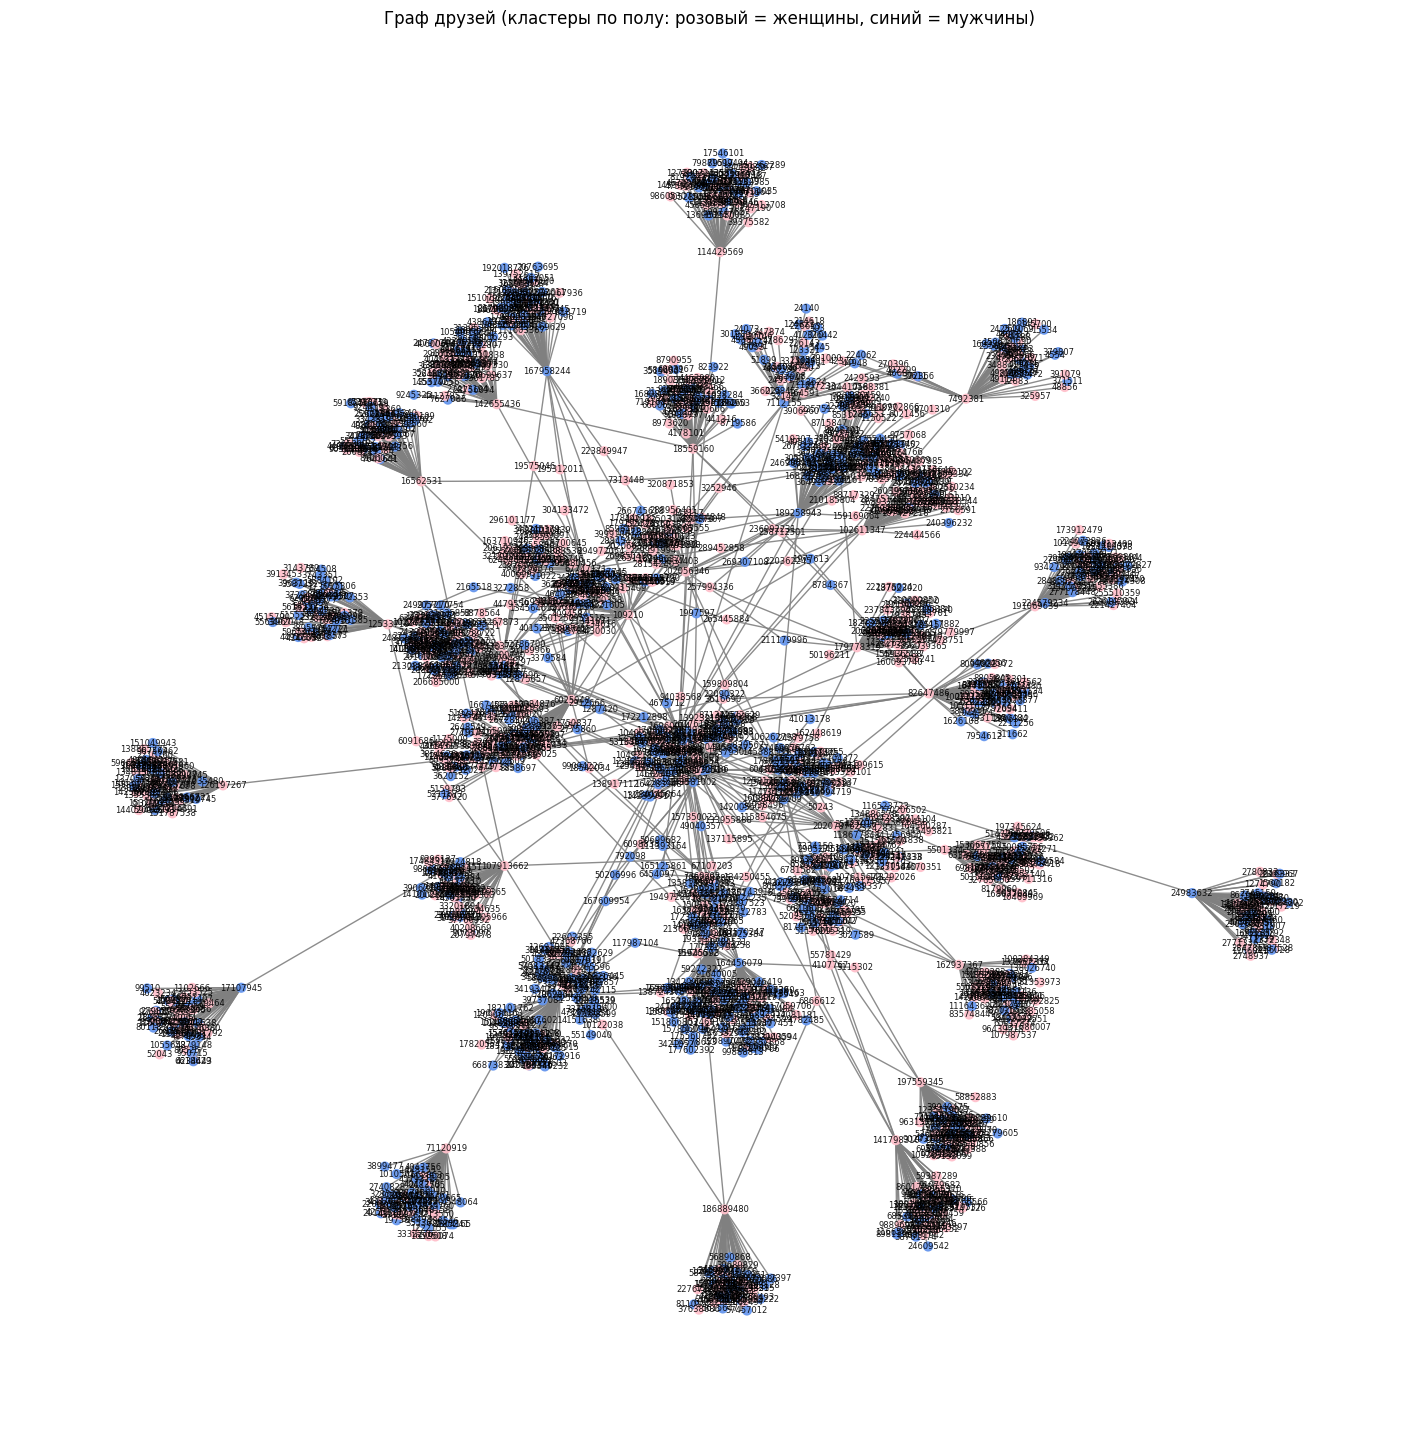

In [59]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Загружаем CSV, который содержит пол и города
df = pd.read_csv(f"friends_graph_{central_user_id}.csv")

# Строим граф
G = nx.from_pandas_edgelist(df, "from_id", "to_id")

# --- Собираем пол пользователя из CSV ----
sex_map = {}

# "from" данные
for _, row in df.iterrows():
    if not pd.isna(row["from_sex"]):
        sex_map[row["from_id"]] = int(row["from_sex"])

# "to" данные
for _, row in df.iterrows():
    if not pd.isna(row["to_sex"]):
        sex_map[row["to_id"]] = int(row["to_sex"])

# ---- Цвета по полу ----
def get_color(node):
    sex = sex_map.get(node, 0)
    if sex == 1:
        return "pink"             # женщины
    elif sex == 2:
        return "cornflowerblue"   # мужчины
    return "gray"                 # неизвестно

node_colors = [get_color(n) for n in G.nodes()]

# ---- Рисуем граф ----
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    with_labels=True,
    font_size=6,
    node_size=40,
    edge_color="gray",
    alpha=0.9,
)

plt.title("Граф друзей (кластеры по полу: розовый = женщины, синий = мужчины)")
plt.show()


In [63]:
!pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import pandas as pd

# Загружаем CSV
df = pd.read_csv("friends_graph_253997298.csv")

# Берём только строки, где город друга указан
df_valid = df.dropna(subset=["to_city"])   # убрать пустые

# Группировка: сколько раз каждый город встречается среди друзей
city_counts = df_valid.groupby("to_city").size().sort_values(ascending=False)

# Вывод
print("Количество друзей по городам:")
for city, count in city_counts.items():
    print(f"{city}: {count}")


Количество друзей по городам:
Пенза: 617
Москва: 467
Санкт-Петербург: 150
Саратов: 56
Самара: 39
Казань: 25
Киров: 21
Уфа: 16
Воронеж: 14
Чебоксары: 14
Краснодар: 10
Нижний Новгород: 9
Заречный: 8
Красноярск: 8
Пермь: 7
Сочи: 6
Старый Оскол: 5
Тольятти: 5
Новосибирск: 5
Калининград: 5
Пенза (деревня): 5
Ростов-на-Дону: 4
Элиста: 4
Подольск: 4
Тюмень: 4
Омск: 4
Ливны: 4
Петрозаводск: 3
Ижевск: 3
Марс: 3
Кузнецк: 3
Кострома: 3
Белгород: 3
Владивосток: 3
Хабаровск: 3
Тамбов: 3
Ялта: 3
Тула: 3
Челябинск: 3
Ульяновск: 3
Химки: 3
Zürich: 2
Красногорск: 2
Томск: 2
Липецк: 2
Волгоград: 2
Брянск: 2
Балашиха: 2
Berlin: 2
Альметьевск: 2
Chicago: 2
Delft: 2
Новокуйбышевск: 2
Новороссийск: 2
Екатеринбург: 2
Грозный: 2
Мытищи: 2
Набережные Челны: 2
Туапсе: 2
Саранск: 2
Саров: 2
Смоленск: 2
Симферополь: 2
Псков: 2
Анна: 1
Анапа: 1
Батуми: 1
Белая Холуница: 1
Власово: 1
Витебск: 1
Братск: 1
Великие Луки: 1
Богданович: 1
Бабаево: 1
Shanghai: 1
Sittard: 1
Ho Chi Minh City: 1
Birmingham: 1
Chiang Mai: 1


In [79]:
!pip install geopy


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import plotly.express as px
import time

# === 1. ЧТЕНИЕ CSV ===
df = pd.read_csv("friends_graph_253997298.csv")

# оставим только строки, где есть город
df = df.dropna(subset=["to_city"])

# === 2. ГЕОКОДЕР ===
geolocator = Nominatim(user_agent="vk_friends_mapper")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# готовим таблицу уникальных городов
cities = df["to_city"].unique()

coords = {}

for city in cities:
    try:
        location = geocode(city + ", Russia")   # уточняем страну
        if location:
            coords[city] = (location.latitude, location.longitude)
            print(f"Город найден: {city} → {coords[city]}")
        else:
            coords[city] = (None, None)
            print(f"Не найдено: {city}")
    except:
        coords[city] = (None, None)
        print(f"⚠ Ошибка геокодирования: {city}")

# === 3. ДОБАВЛЯЕМ КООРДИНАТЫ В DATAFRAME ===
df["lat"] = df["to_city"].map(lambda x: coords[x][0])
df["lon"] = df["to_city"].map(lambda x: coords[x][1])

# удаляем строки без координат
df_map = df.dropna(subset=["lat", "lon"])

print("Города на карте:")
print(df_map[["to_city", "lat", "lon"]].drop_duplicates())

# === 4. СТРОИМ КАРТУ ===

city_count = df_map.groupby(["to_city", "lat", "lon"]).size().reset_index(name="friends_count")

fig = px.scatter_mapbox(
    city_count,
    lat="lat",
    lon="lon",
    size="friends_count",
    size_max=25,
    color="friends_count",
    hover_name="to_city",
    hover_data={"friends_count": True, "lat": False, "lon": False},
    zoom=3,
    height=650
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0, "t":40, "l":0, "b":0},
    title="Карта друзей по городам (Plotly Mapbox)"
)

fig.show()


Город найден: Пенза → (53.1953477, 45.0190437)
Город найден: Санкт-Петербург → (59.9606739, 30.1586551)
Город найден: Москва → (55.625578, 37.6063916)
Город найден: Саратов → (51.530018, 46.034683)
Город найден: Заречный → (56.8149706, 61.3205936)
Город найден: Краснодар → (45.0351532, 38.9772396)
Город найден: Ливны → (52.4253859, 37.6089)
Город найден: Сочи → (43.5854823, 39.723109)
Город найден: Кузнецк → (53.112514, 46.600727)
Город найден: Самара → (53.1956255, 50.1014927)
Город найден: Milano → (55.6764429, 37.5359478)
Город найден: Пермь → (58.0108531, 56.2318528)
Город найден: Мытищи → (55.9094928, 37.7339358)
Город найден: Тамбов → (52.7216164, 41.4523988)
Город найден: Псков → (57.8173923, 28.3343465)
Город найден: Berlin → (54.006485, 61.192986)
Город найден: Zürich → (55.7430405, 37.5062203)
Город найден: Старый Оскол → (51.298038, 37.833202)
Не найдено: Хайфа
Город найден: Кострома → (57.7679158, 40.9269141)
Город найден: Семей → (55.7542886, 52.5110435)
Город найден: Крас

RateLimiter caught an error, retrying (0/2 tries). Called with (*("Saint John's, Russia",), **{}).
Traceback (most recent call last):
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connection.py", line 565, in getresponse
    httplib_response = super().getresponse()
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\http\client.py", line 1430, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\http\client.py", line 331, in begin
    version, status, reason = self._read_status()
                              ~~~~~~~~~~~~~~~~~^^
  File "c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\http\client.py", line 292, in _read_status
    line = str(self.fp.readline(_MAXLINE + 1), "iso-8859-1")


Город найден: Saint John's → (59.9514074, 30.321897)
Город найден: Климово → (57.1186361, 35.1441991)
Город найден: Кирсанов → (52.654755, 42.72496)
Город найден: Анапа → (44.894272, 37.316887)
Город найден: Чапаевск → (52.981285, 49.711193)
Город найден: Приволжье → (57.991085, 39.218506)
Город найден: Новокуйбышевск → (53.099243, 49.948364)
Город найден: Куйбышев → (55.4454258, 78.3222294)
Город найден: Ессентуки → (44.0470042, 42.8576575)
Город найден: Щелково → (55.9206499, 37.9915576)
Город найден: Марс → (54.3478254, 48.8232985)
Город найден: Chicago → (55.6997579, 37.6352665)
Город найден: Уссурийск → (43.7972447, 131.9520752)
Город найден: Зеленодольск → (55.8477605, 48.5097031)
Город найден: Ефремов → (53.141834, 38.116188)
Город найден: Коломна → (55.0938743, 38.7670121)
Город найден: Одесса → (43.0637267, 43.2098205)
Город найден: Киев → (59.600199, 55.205642)
Город найден: Евлашево → (53.1119, 46.8311)
Город найден: Мурманск → (68.970665, 33.07497)
Город найден: Обнинск → (

C:\Users\User\AppData\Local\Temp\ipykernel_19708\2197626561.py:49: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

